## 기본 통계량 및 분포 분석

# 지역별 숙소 개수 -> 현황 및 시각화 추가 할 거 있으면 추가

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv")
test_df = df.copy()

In [32]:
selected_cols =[
'id',
'name',
'description',
'host_id',
'host_since',
'host_response_time',
'host_response_rate',
'host_acceptance_rate',
'host_is_superhost',
'neighbourhood_cleansed',
'neighbourhood_group_cleansed',
'latitude',
'longitude',
'property_type',
'room_type',
'accommodates',
'bedrooms',
'beds',
'amenities',
'price',
'availability_365',
'number_of_reviews',
'number_of_reviews_ltm',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month']

df = test_df[selected_cols]
df2 = df.copy()

In [33]:
df2.shape

(22308, 37)

In [34]:
df2['neighbourhood_group_cleansed'].value_counts()

neighbourhood_group_cleansed
Manhattan        10205
Brooklyn          7455
Queens            3420
Bronx              912
Staten Island      316
Name: count, dtype: int64

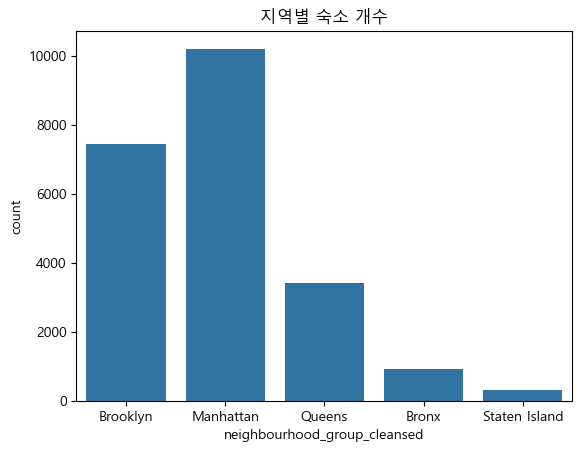

In [35]:
sns.countplot(data=df2, x='neighbourhood_group_cleansed') 
plt.title('지역별 숙소 개수')
plt.show()

1. 시각화 해석
- 뉴욕airbnb숙소는 manhattan과 brooklyn 지역에 많이 분포되어 있고 특히 manhattan이 가장 많은 숙소를 보유한 지역으로 나타남. 반면 bronx랑 statenlsland는 다른 지역에 비해 상대적으로 적은 숙소수를 나타내고 있다.

In [36]:
df2['room_type'].value_counts()

room_type
Entire home/apt    12664
Private room        9186
Hotel room           372
Shared room           86
Name: count, dtype: int64

# 지역별 숙소 유형 개수(한번 확인해봤음)

In [37]:
pd.crosstab(df2['neighbourhood_group_cleansed'],df2['room_type']).reset_index()

room_type,neighbourhood_group_cleansed,Entire home/apt,Hotel room,Private room,Shared room
0,Bronx,370,0,542,0
1,Brooklyn,3775,17,3626,37
2,Manhattan,6954,347,2882,22
3,Queens,1408,8,1977,27
4,Staten Island,157,0,159,0


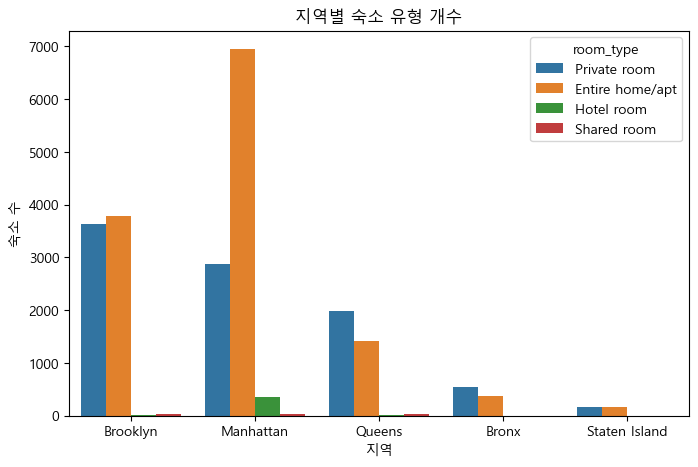

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=df2, x='neighbourhood_group_cleansed', hue='room_type')
plt.title('지역별 숙소 유형 개수')
plt.xlabel('지역')
plt.ylabel('숙소 수')
plt.show()

1. 시각화 해석
- 지역별 숙소 유형 분포를 살펴보면 Entire home/apt 유형은 Manhattan 지역에서 가장 높은 비중을 차지하는 것으로 나타났고, 반면 Private room 유형은 Brooklyn 지역에서 상대적으로 더 많이 분포하는 경향을 보인다. 나머지는 뭐....

# 개수보단 확률로 시각화 한번 도전!

In [ ]:
# normalize로 비율 분석(지역별 숙소유형 개수 시각화)
ct = pd.crosstab(df2['neighbourhood_group_cleansed'], df2['room_type'], normalize='index').round(2)

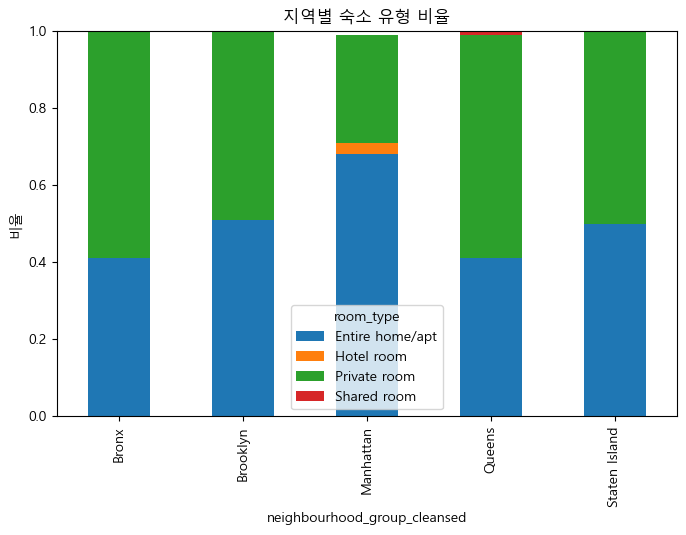

In [ ]:
# 음... 망했다....
ct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("지역별 숙소 유형 비율")
plt.ylabel("비율")
plt.show()

In [ ]:
# 지역별 숙소 개수 비율로 시각화
df2['neighbourhood_group_cleansed'].value_counts(normalize=False)

neighbourhood_group_cleansed
Manhattan        10205
Brooklyn          7455
Queens            3420
Bronx              912
Staten Island      316
Name: count, dtype: int64

In [52]:
region = df2['neighbourhood_group_cleansed'].value_counts(normalize=True) * 100
region = region.round(2)

region

neighbourhood_group_cleansed
Manhattan        45.75
Brooklyn         33.42
Queens           15.33
Bronx             4.09
Staten Island     1.42
Name: proportion, dtype: float64

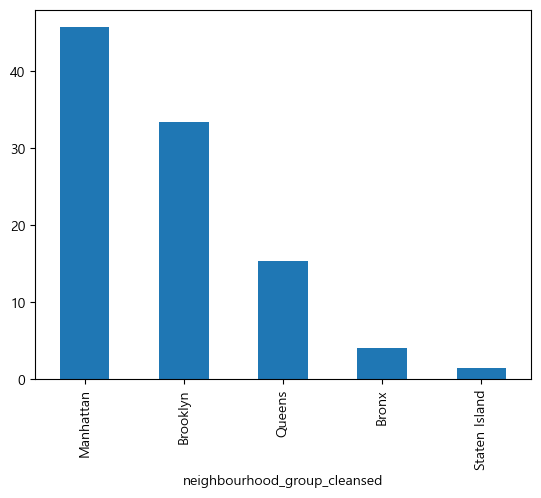

In [55]:
region.plot(kind='bar')
plt.show()

In [56]:
# price "$", "," 제거 -> float형태로 변경
df2['price'] = (df2['price'].str.replace("$", "").str.replace(",","").astype(float))
df2['price']

df2['log_price'] = np.log1p(df2['price'])

q1_log = np.percentile(df2['log_price'], 25)
q3_log = np.percentile(df2['log_price'], 75)
iqr_log = q3_log - q1_log

lower_log = q1_log - 1.5 * iqr_log
upper_log = q3_log + 1.5 * iqr_log

log_outliers = df2.loc[(df2['log_price'] > upper_log) | (df2['log_price'] < lower_log)]
print(f"로그 변환 후 이상치 개수: {len(log_outliers)}")

df_processed_log = df2.loc[df2['log_price'] > upper_log].copy()
df_processed_log.describe()

로그 변환 후 이상치 개수: 253


,id,host_id,latitude,longitude,accommodates,bedrooms,beds,price,availability_365,number_of_reviews,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
count,2.410000e+02,2.410000e+02,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,...,93.000000,93.000000,93.000000,93.000000,241.000000,241.000000,241.000000,241.000000,93.000000,241.000000
mean,7.187696e+17,2.578366e+08,40.743486,-73.972719,6.883817,2.365145,3.095436,2649.759336,274.609959,7.792531,...,4.909140,4.934409,4.869677,4.711290,72.273859,53.290456,3.170124,0.004149,0.418925,7.621052
std,4.687417e+17,2.094228e+08,0.039462,0.039655,4.628151,2.113318,3.512362,2947.038941,111.980827,25.061726,...,0.175007,0.180395,0.206595,0.359372,202.127702,198.049191,10.164896,0.064416,0.657269,0.605080
min,1.749660e+05,4.972670e+05,40.576010,-74.098650,1.000000,0.000000,0.000000,1136.000000,0.000000,0.000000,...,4.000000,3.500000,4.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.020000,7.036148
25%,4.992023e+07,3.947710e+07,40.722780,-73.989240,3.000000,1.000000,1.000000,1333.000000,180.000000,0.000000,...,4.880000,4.940000,4.830000,4.600000,1.000000,1.000000,0.000000,0.000000,0.090000,7.195937
50%,8.306756e+17,3.082798e+08,40.752656,-73.975831,6.000000,2.000000,2.000000,1707.000000,337.000000,0.000000,...,5.000000,5.000000,5.000000,4.810000,4.000000,2.000000,0.000000,0.000000,0.170000,7.443078
75%,1.111666e+18,4.655797e+08,40.764694,-73.967018,10.000000,3.000000,4.000000,2500.000000,364.000000,4.000000,...,5.000000,5.000000,5.000000,5.000000,20.000000,7.000000,1.000000,0.000000,0.380000,7.824446
max,1.355509e+18,6.639210e+08,40.898020,-73.726981,16.000000,15.000000,42.000000,20000.000000,365.000000,222.000000,...,5.000000,5.000000,5.000000,5.000000,1194.000000,1194.000000,45.000000,1.000000,3.170000,9.903538
